# Tugas Praktikum 2: Praproses Data
**Nama:** Muhammad Farid Wijdan  
**NRP:** 5054251042  
**Dataset:** House Prices - Advanced Regression Techniques (`train.csv`)

Notebook ini membersihkan data, menangani outlier, melakukan encoding dan standardisasi, lalu mereduksi fitur dengan PCA.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lokasi = Path.cwd()
sumber = lokasi / 'praktikum-2' / 'train.csv'
if not sumber.exists():
    sumber = lokasi.parent / 'praktikum-2' / 'train.csv'
data = pd.read_csv(sumber)
print('Lima baris pertama:')
display(data.head())
print('Ukuran data:', data.shape)
print('Info kolom:')
data.info()

Matplotlib is building the font cache; this may take a moment.


Lima baris pertama:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Ukuran data: (1460, 81)
Info kolom:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nul

## 1. Nilai hilang
Kolom yang hilang lebih dari 50% dihapus. Nilai kosong pada kolom angka diisi median, sedangkan kolom kategori diisi modus. Median tidak terlalu dipengaruhi nilai ekstrem.

In [2]:
hilang = data.isna().sum().sort_values(ascending=False)
print('Jumlah nilai hilang per atribut (yang memiliki nilai kosong):')
display(hilang[hilang > 0].to_frame('Jumlah hilang'))
kolom_hapus = hilang[hilang > len(data) * 0.5].index.tolist()
bersih = data.drop(columns=kolom_hapus).copy()
print('Kolom dihapus:', kolom_hapus)

for kolom in bersih.columns:
    if bersih[kolom].isna().any():
        if pd.api.types.is_numeric_dtype(bersih[kolom]):
            bersih[kolom] = bersih[kolom].fillna(bersih[kolom].median())
        else:
            bersih[kolom] = bersih[kolom].fillna(bersih[kolom].mode()[0])
print('Total nilai hilang setelah dibersihkan:', bersih.isna().sum().sum())
print('Ukuran setelah pembersihan:', bersih.shape)

Jumlah nilai hilang per atribut (yang memiliki nilai kosong):


,Jumlah hilang
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageCond,81
GarageType,81


Kolom dihapus: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Total nilai hilang setelah dibersihkan: 0
Ukuran setelah pembersihan: (1460, 76)


## 2. Outlier
Boxplot digunakan untuk melihat nilai ekstrem pada empat atribut ukuran rumah. Nilai di luar batas 1,5 × IQR dibatasi ke batas bawah atau atas. `SalePrice` tidak diubah karena merupakan target yang ingin diprediksi.

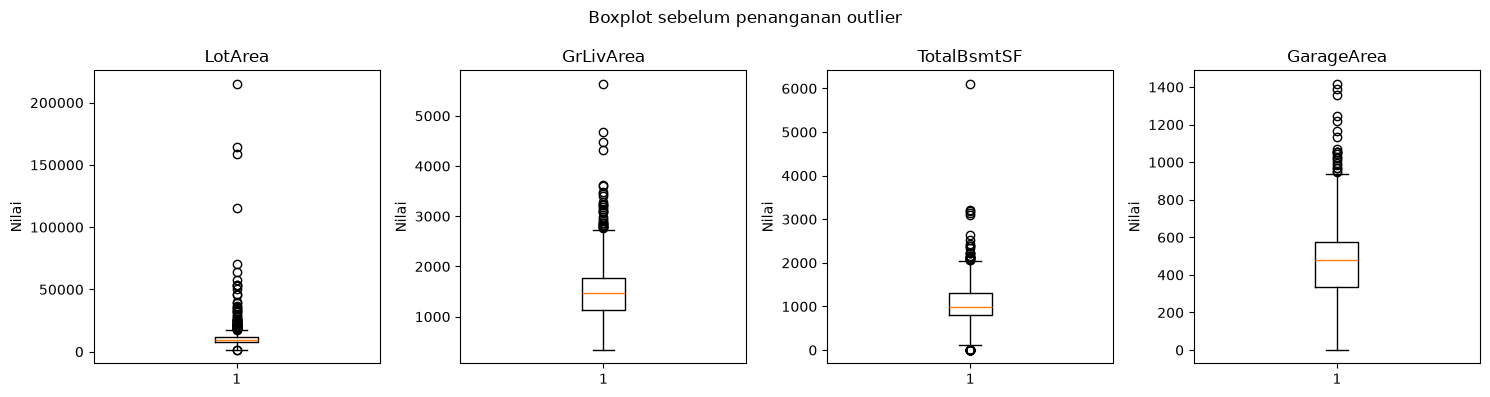

Nilai yang disesuaikan per kolom: {'LotArea': 69, 'GrLivArea': 31, 'TotalBsmtSF': 61, 'GarageArea': 21}


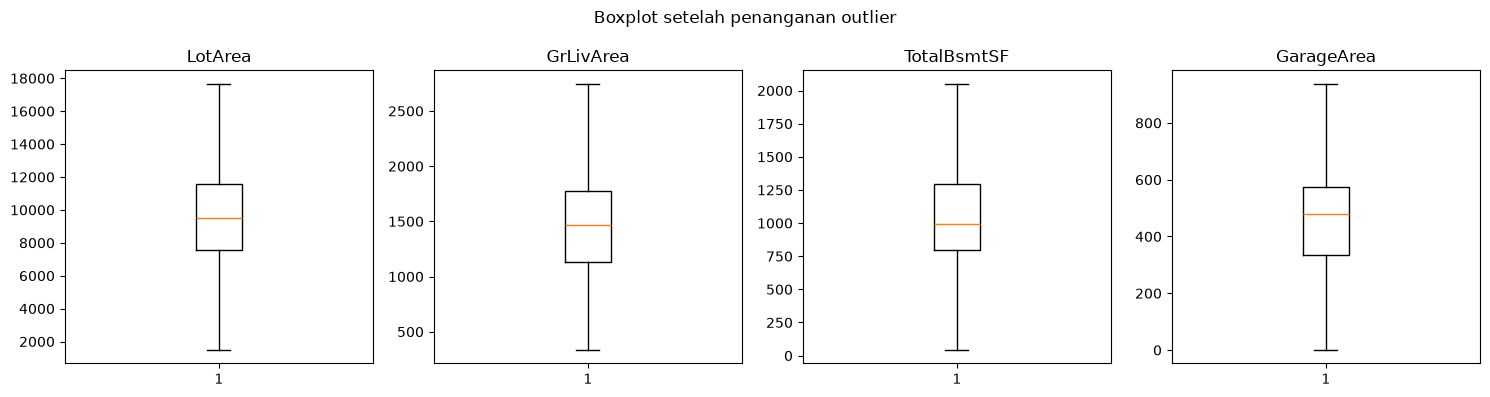

In [3]:
fitur_outlier = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, kolom in zip(axes, fitur_outlier):
    ax.boxplot(bersih[kolom].dropna())
    ax.set_title(kolom)
    ax.set_ylabel('Nilai')
plt.suptitle('Boxplot sebelum penanganan outlier')
plt.tight_layout()
plt.show()

jumlah_outlier = {}
for kolom in fitur_outlier:
    q1, q3 = bersih[kolom].quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    jumlah_outlier[kolom] = int(((bersih[kolom] < batas_bawah) | (bersih[kolom] > batas_atas)).sum())
    bersih[kolom] = bersih[kolom].clip(batas_bawah, batas_atas)
print('Nilai yang disesuaikan per kolom:', jumlah_outlier)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, kolom in zip(axes, fitur_outlier):
    ax.boxplot(bersih[kolom])
    ax.set_title(kolom)
plt.suptitle('Boxplot setelah penanganan outlier')
plt.tight_layout()
plt.show()

## 3. Korelasi dan transformasi
Sebelum encoding, pasangan atribut angka dengan korelasi absolut di atas 0,90 diperiksa. Dari setiap pasangan, satu atribut dibuang agar informasi yang hampir sama tidak berulang. `Id` dan `SalePrice` tidak ikut dihitung sebagai fitur. Selanjutnya kategori diubah menjadi kolom one-hot dan semua fitur distandardisasi dengan rumus z-score.

In [4]:
X = bersih.drop(columns=['Id', 'SalePrice']).copy()
angka = X.select_dtypes(include='number')
korelasi = angka.corr().abs()
kolom_atas = korelasi.where(np.triu(np.ones(korelasi.shape), k=1).astype(bool))
pasangan = [(baris, kolom, round(float(nilai), 3))
           for kolom in kolom_atas.columns
           for baris, nilai in kolom_atas[kolom].dropna().items()
           if nilai > 0.90]
kolom_korelasi = sorted({kolom for _, kolom, _ in pasangan})
print('Pasangan korelasi > 0,90:', pasangan)
print('Kolom yang dibuang:', kolom_korelasi)
X = X.drop(columns=kolom_korelasi)

X_encoded = pd.get_dummies(X, dtype=int)
deviasi = X_encoded.std(ddof=0)
kolom_konstan = deviasi[deviasi == 0].index.tolist()
X_encoded = X_encoded.drop(columns=kolom_konstan)
X_scaled = (X_encoded - X_encoded.mean()) / X_encoded.std(ddof=0)
print('Ukuran setelah one-hot encoding:', X_encoded.shape)
print('Kolom konstan yang dibuang:', kolom_konstan)
print('Total nilai hilang setelah standardisasi:', X_scaled.isna().sum().sum())
display(X_scaled.iloc[:5, :8])

Pasangan korelasi > 0,90: []
Kolom yang dibuang: []
Ukuran setelah one-hot encoding: (1460, 271)
Kolom konstan yang dibuang: []
Total nilai hilang setelah standardisasi: 0


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea
0,0.073375,-0.220875,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104
1,-0.872563,0.460320,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750
2,0.073375,-0.084636,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915
3,0.309859,-0.447940,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750
4,0.073375,0.641972,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489


## 4. PCA dan dataset akhir
PCA memakai SVD dari NumPy. Komponen dipilih sampai paling sedikit 95% variasi fitur terwakili. Hasil PCA adalah fitur baru, sedangkan `SalePrice` tetap dalam nilai aslinya.

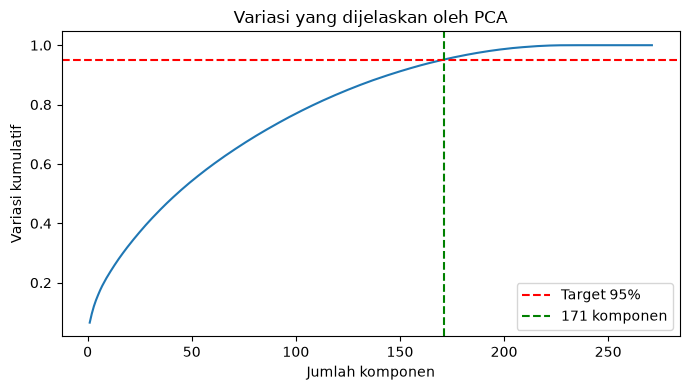

Komponen PCA: 171
Variasi terwakili: 95.15 %
Ukuran dataset akhir: (1460, 173)
Nilai hilang dataset akhir: 0


,Id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC163,PC164,PC165,PC166,PC167,PC168,PC169,PC170,PC171,SalePrice
0,1,4.096605,2.002455,-1.818228,1.881606,0.157784,-1.761496,-0.177454,0.183736,-1.100666,...,0.052666,-0.025801,-0.020372,-0.143401,0.066430,0.064143,-0.234492,0.073601,0.157041,208500
1,2,0.203552,-3.529321,-0.714953,0.474006,0.037108,-0.180844,0.942286,0.540363,-1.144320,...,-0.376121,-0.828904,0.540903,2.512197,-1.104546,-0.105763,-0.207659,0.925591,-0.097933,181500
2,3,4.938979,0.917514,-0.870942,2.602760,-0.156535,-2.575993,0.111317,0.672064,-1.472235,...,-0.524490,-0.268774,0.119831,0.083464,-0.001629,-0.903917,0.297289,-0.034135,-0.056391,223500
3,4,-1.876707,0.947717,2.046177,1.400726,0.760865,-0.112509,2.151726,-0.224481,1.213847,...,1.132547,0.205819,0.427022,0.845757,-0.339956,0.043312,-0.126112,-0.615611,1.101345,140000
4,5,6.668112,0.383493,1.349339,3.751199,-0.154311,-1.478089,-0.476119,1.124298,-2.188265,...,-0.158107,0.734816,0.343918,-0.047685,-0.111145,0.097060,0.471107,-0.258171,-0.390513,250000


In [5]:
U, singular, Vt = np.linalg.svd(X_scaled.to_numpy(), full_matrices=False)
variasi = singular**2 / np.sum(singular**2)
variasi_kumulatif = np.cumsum(variasi)
jumlah_komponen = int(np.searchsorted(variasi_kumulatif, 0.95) + 1)
skor_pca = U[:, :jumlah_komponen] * singular[:jumlah_komponen]
kolom_pca = [f'PC{i+1}' for i in range(jumlah_komponen)]
hasil = pd.DataFrame(skor_pca, columns=kolom_pca)
hasil.insert(0, 'Id', bersih['Id'].to_numpy())
hasil['SalePrice'] = bersih['SalePrice'].to_numpy()
tujuan = sumber.parent
file_csv = tujuan / '5054251042_Muhammad_Farid_Wijdan_Tugas_Praproses_Data.csv'
hasil.to_csv(file_csv, index=False)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(variasi_kumulatif)+1), variasi_kumulatif)
plt.axhline(0.95, color='red', linestyle='--', label='Target 95%')
plt.axvline(jumlah_komponen, color='green', linestyle='--', label=f'{jumlah_komponen} komponen')
plt.xlabel('Jumlah komponen')
plt.ylabel('Variasi kumulatif')
plt.title('Variasi yang dijelaskan oleh PCA')
plt.legend()
plt.tight_layout()
plt.show()
print('Komponen PCA:', jumlah_komponen)
print('Variasi terwakili:', round(float(variasi_kumulatif[jumlah_komponen-1])*100, 2), '%')
print('Ukuran dataset akhir:', hasil.shape)
print('Nilai hilang dataset akhir:', hasil.isna().sum().sum())
display(hasil.head())

## Kesimpulan
Data awal berisi 1460 rumah dan 81 kolom. Setelah kolom dengan banyak nilai kosong dibuang, nilai lain diisi dengan median atau modus. Outlier pada empat atribut ukuran dibatasi memakai IQR tanpa menghapus baris. Fitur berkorelasi tinggi dikurangi, kategori diubah dengan one-hot encoding, dan fitur distandardisasi. Dataset akhir menggunakan komponen PCA yang mencakup sedikitnya 95% variasi fitur, ditambah `Id` dan `SalePrice`.